<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Pharma_Industry (1).csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
# Display information about the DataFrame
display(df.info())

# Display descriptive statistics of the DataFrame
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


None

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


### Task 1: Exploratory Data Analysis (EDA)

#### 1. Visualize Feature Distributions (Histograms and Box Plots)

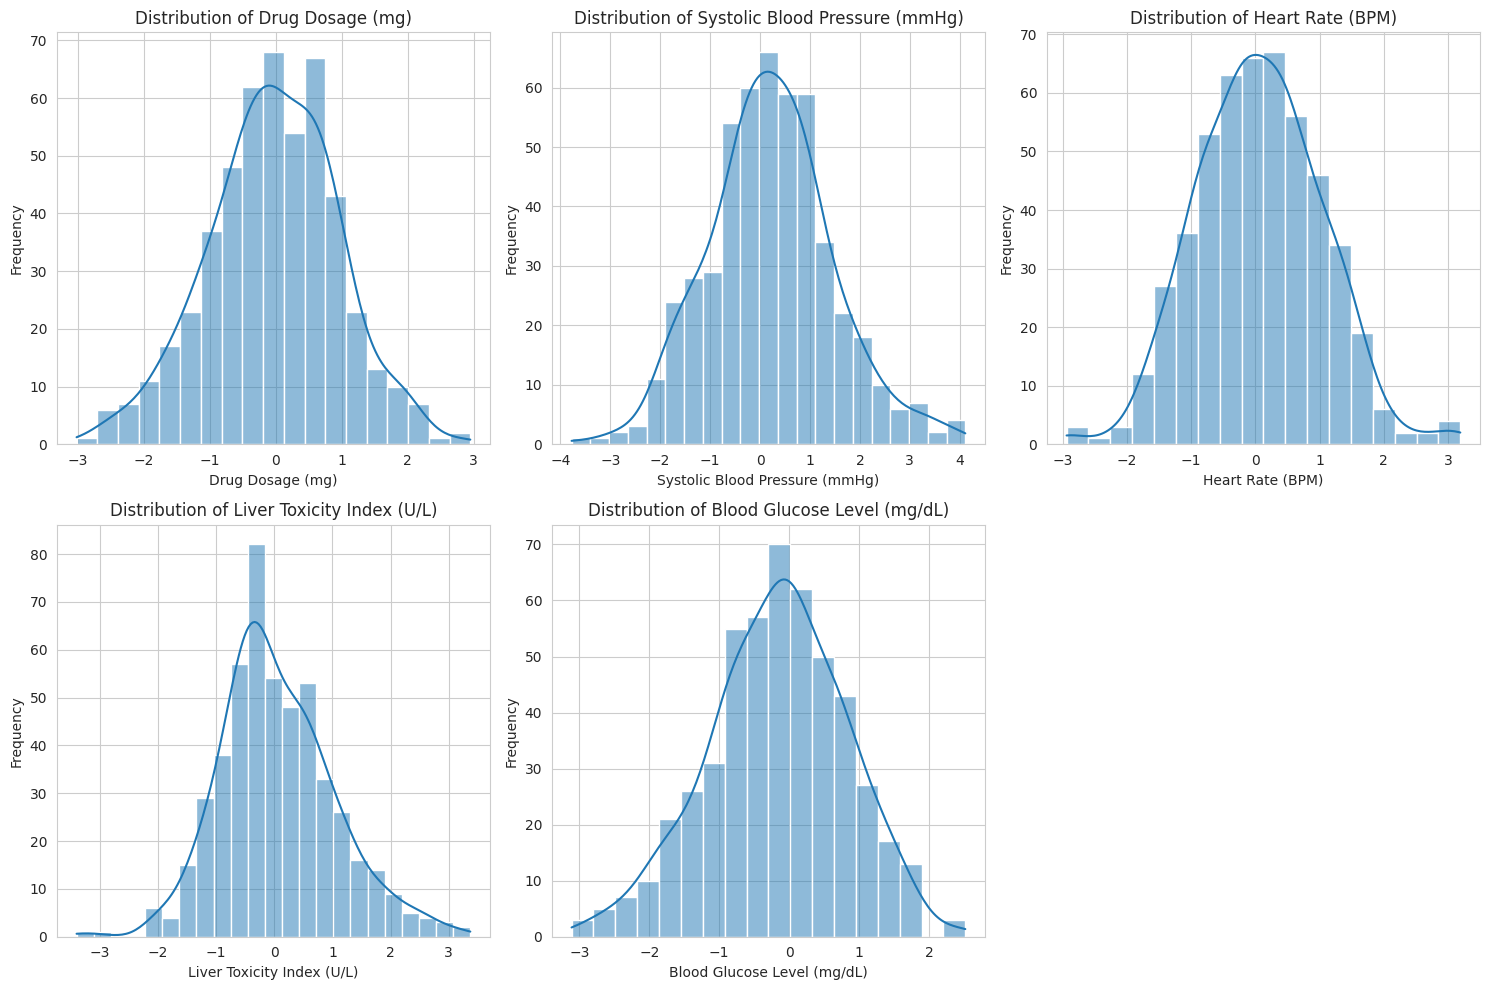

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Get numerical columns (excluding the target variable 'Drug Response')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('Drug Response')

# Create histograms for all numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

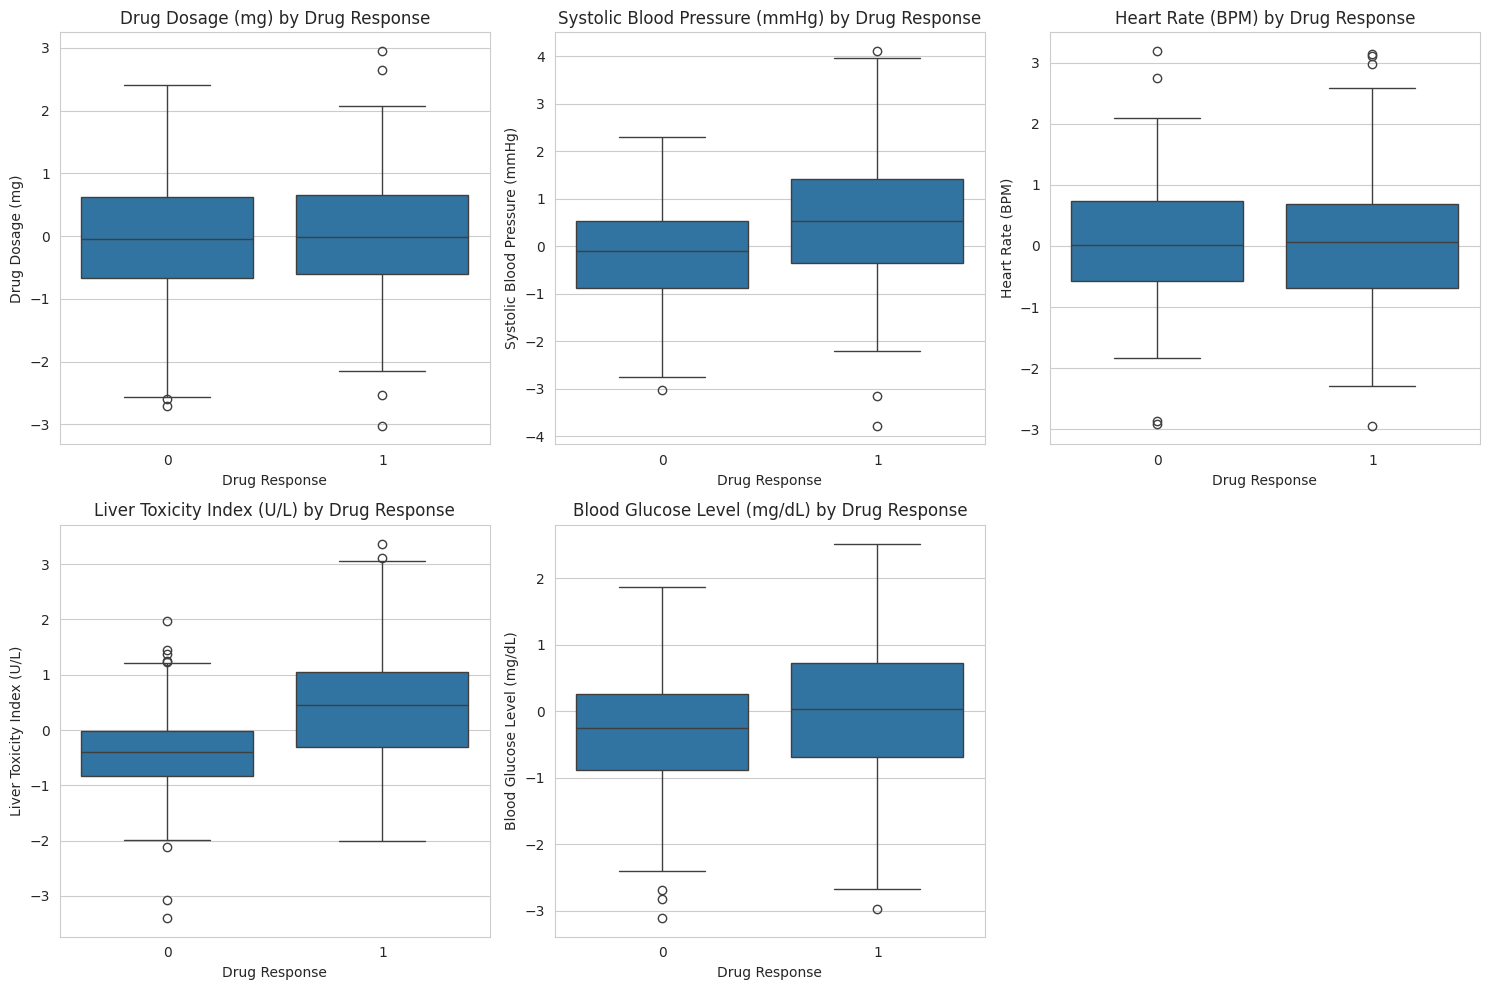

In [5]:
# Create box plots for all numerical features, grouped by 'Drug Response'
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='Drug Response', y=col, data=df)
    plt.title(f'{col} by Drug Response')
    plt.xlabel('Drug Response')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### 2. Investigate Feature Correlations

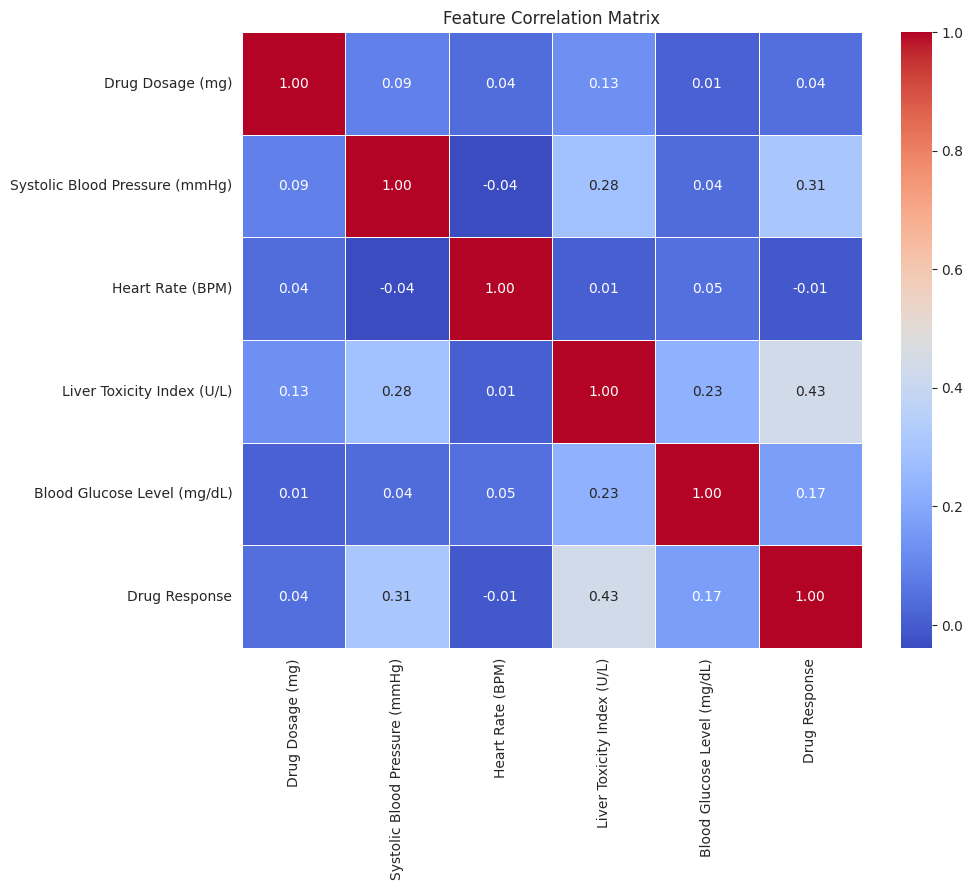

In [6]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Matrix')
plt.show()

### Task 2: Data Preprocessing

#### 1. Encode categorical variables if necessary (Not needed as all features are numerical)

#### 2. Split the dataset into training and testing sets

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (400, 5)
X_test shape: (100, 5)
y_train shape: (400,)
y_test shape: (100,)


### Task 3: Data Visualization

#### 1. Visualize class distributions to gauge dataset balance or imbalance.

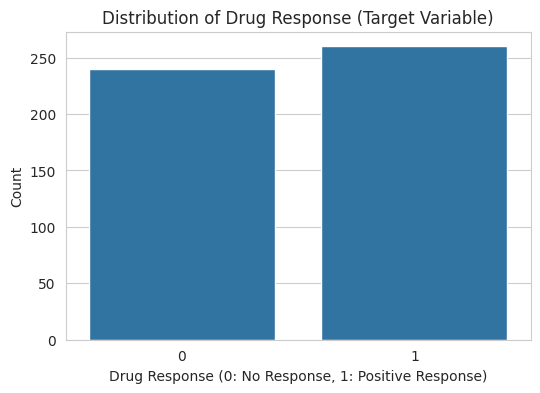


Class Counts:
Drug Response
1    260
0    240
Name: count, dtype: int64

Class Percentages:
Drug Response
1    52.0
0    48.0
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Drug Response (Target Variable)')
plt.xlabel('Drug Response (0: No Response, 1: Positive Response)')
plt.ylabel('Count')
plt.show()

# Display the count and percentage of each class
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("\nClass Counts:")
print(class_counts)
print("\nClass Percentages:")
print(class_percentages)

#### 2. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

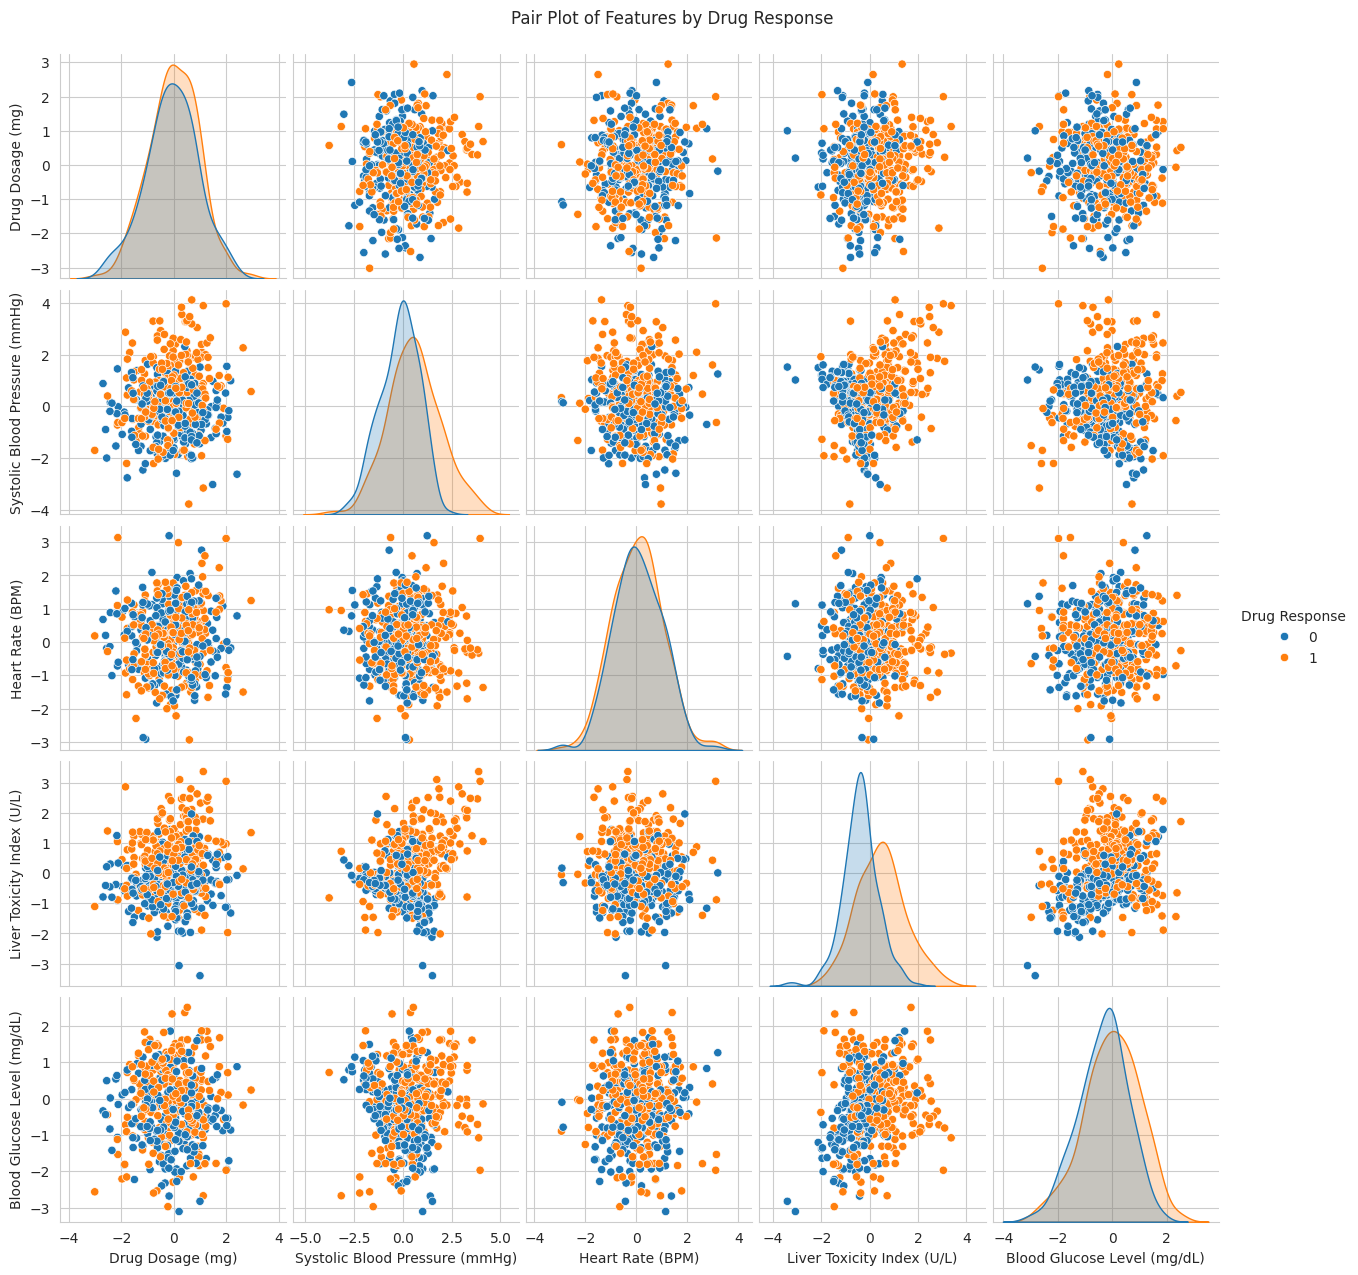

In [9]:
# Create a pair plot to visualize relationships between numerical features and the target variable
# This might take a moment to generate
sns.pairplot(df, hue='Drug Response', diag_kind='kde')
plt.suptitle('Pair Plot of Features by Drug Response', y=1.02)
plt.show()

### Task 4: SVM Implementation

#### 1. Implement a basic SVM classifier using Python libraries like scikit-learn.
#### 2. Train the SVM model on the training data.
#### 3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize the SVM classifier with a linear kernel for simplicity first
# We will experiment with different kernels and hyperparameters later in Task 6
svm_model = SVC(kernel='linear', random_state=42)

# Train the SVM model on the training data
svm_model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = svm_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"SVM Model Performance (Linear Kernel):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

SVM Model Performance (Linear Kernel):
Accuracy: 0.7200
Precision: 0.7609
Recall: 0.6731
F1-Score: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100


Confusion Matrix:
[[37 11]
 [17 35]]


### Task 5: Visualization of SVM Results

#### 1. Visualize classification results on the testing data.

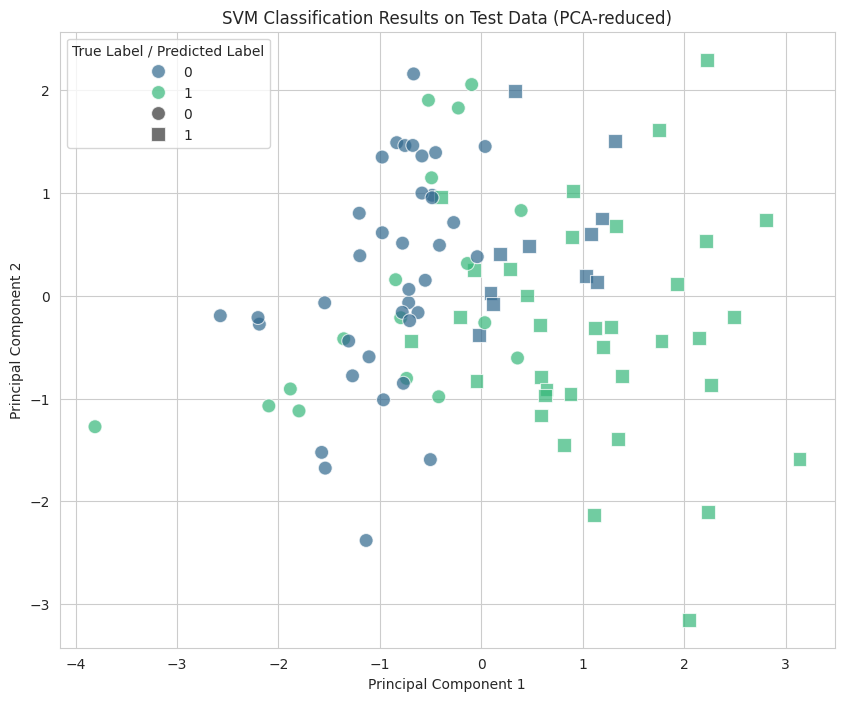

Interpretation: Circles represent true class 0, Squares represent true class 1. Colors indicate actual classes. Shapes indicate predicted classes. Overlapping shapes and colors show correct predictions. Mismatched shapes and colors show misclassifications.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Due to the high dimensionality (5 features), direct 2D/3D visualization of decision boundaries is hard.
# We'll use PCA to reduce dimensions to 2 for visualization.
# This will give us a general idea, but is not a perfect representation of the 5D decision boundary.

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Create a scatter plot of the PCA-transformed test data
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=y_test,
    style=y_pred,
    palette='viridis',
    markers=['o', 's'],
    s=100,
    alpha=0.7,
    edgecolor='w'
)

plt.title('SVM Classification Results on Test Data (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='True Label / Predicted Label', loc='best')
plt.grid(True)
plt.show()

print("Interpretation: Circles represent true class 0, Squares represent true class 1. Colors indicate actual classes. Shapes indicate predicted classes. Overlapping shapes and colors show correct predictions. Mismatched shapes and colors show misclassifications.")

### Task 6: Parameter Tuning and Optimization

#### 1. Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel type
    'gamma': ['scale', 'auto'], # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
    'degree': [2, 3, 4] # Degree for 'poly' kernel
}

# Initialize GridSearchCV with an SVM classifier
# We will use cross-validation (cv=5) for robust evaluation
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

# Print the best parameters found
print(f"\nBest parameters: {grid_search.best_params_}")

# Print the best cross-validation score
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

# Get the best model
best_svm_model = grid_search.best_estimator_

# Make predictions on the test data with the best model
y_pred_tuned = best_svm_model.predict(X_test)

# Evaluate the best model's performance on the test set
print("\nBest SVM Model Performance (Tuned Parameters):")
print(classification_report(y_test, y_pred_tuned))

Starting GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
GridSearchCV completed.

Best parameters: {'C': 10, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation F1-score: 0.7797

Best SVM Model Performance (Tuned Parameters):
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        48
           1       0.71      0.77      0.74        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100

